# Mathics3 Jupyter Kernel Introduction

Here we describe some features of the Mathics3 Jupyter Kernel.


## Jupyter Kernel versus Jupyter Extension

A Jupyter Kernel is a separate process that interacts with your browser running Jupyter browser code.

The Mathics3 Jupyter Kernel uses modules from the standard IPython Jupyter Kernel,`ipykernel`. However, it is its own kernel and runs in a process separate from the browser. As such, currently, it does not run inside a browser like [pyodide](https://pyodide.org/en/stable/).

There is a Mathics3 Jupyter Extension in [Mathics3-notebook-frontends](https://github.com/Mathics3/Mathics3-notebook-frontends). The Mathics3 Jupyter Extension _does_ run completely inside the browser via `pyodide`.

## Markdown Cells

A notebook consists of a number of _cells_ like this one. 

This particular cell, whose purpose is purely descriptive (as opposed to a Mathics3 calculation), uses [Markdown](https://en.wikipedia.org/wiki/Markdown).

Markdown is useful for introducing decscriptive text around your Mathics3 expressions or code.

By using Markdown Headings, `#`, `##`, etc., you can to elide groups of cells, under the heading.

To tag a notebook cell as containing markdown text, select "Markdown" in the Dropdown Menu of the Toolbar:

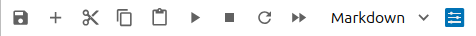

(Other choices of the dropdown are `Code` and `Raw`.

To see the markup or edit a markdown cell just select the markdown cell and double click.

To render the text after editing, select the cell and entry "Run" from the toolbar menu, or enter Shift-Enter.




## Basic Markdown Markup
Inside cells tagged as Markdown, you can format or tag text using the syntax normally found in Markdown text. 

Here is an example: 

* *italicized text*, 
* **bold text**
* ~strikedown text~, 
* `code text`, and 
* mathematical inline text: $\sqrt{(x^2)}$

--- 

Normal markdown text also supports lists (seen above), definition lists, ordered lists, task lists, URLs, and other things.

See the [Markdown Cheat Sheet](https://www.markdownguide.org/cheat-sheet/) for a more complete list.

## Notebook File Loading

On entry of a pre-existing notebook, input cells and the output due to a _prior_ evaluation of cells are shown.

However, internal values of any variables set due to a prior execution are lost. Therefore, it is often useful to hit the 
menubar refresh button 
<svg xmlns="http://w3.org"
  width="14" height="14" viewBox="0 0 24 24" style="display: inline-block; vertical-align: middle; margin: 0 2px;">
  <g class="jp-icon3" fill="#616161">
    <path d="M4 18l8.5-6L4 6v12zm9-12v12l8.5-6L13 6z"/>
  </g>
</svg> 
just to the left of the `Code` dropdown menu.

This will restart the Mathics3 Jupyter kernel and sequentially evaluate all of the cell input data. In the process, variables and 
other state information will get set to the values as they appeared initially.

To run cell input one by one, use the 
<svg xmlns="http://w3.org" 
  width="14" height="14" viewBox="0 0 24 24" 
  style="display: inline-block; vertical-align: middle; margin: 0 2px;">
   <g class="jp-icon3" fill="#616161">
    <path d="M8 5v14l11-7z"/>
   </g>
</svg> 
icon to the left of the restart button.



## Entering Mathics3 Expressions

Finally, we get to inputting Mathics3 expressions and seeing its output!

Until Jupyter markdown handling is integrated better with Mathics3, Mathics3 expressions have to be entered in a cell
separate from markdown.


In [1]:
(* Compute Euler's famous equation: *)
E ^ (Pi I)

- 
 1

As seen above, you can add Mathics3 comments before an expression. And, of course, you can put them after an expression too:

In [2]:
30! (* 30 Factorial. All Factorials over 5! have zeros at the end. *)

265252859812191058636308480000000

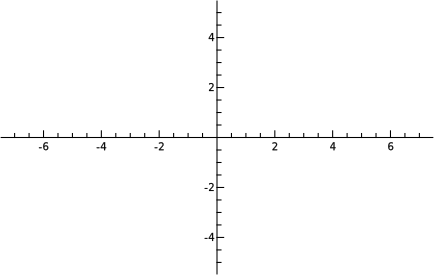

In [3]:
(* The Mathics3 Jupyter Kernel supports Plotting ... *)
Plot[Csc[x], {x, -2Pi, 2Pi}]

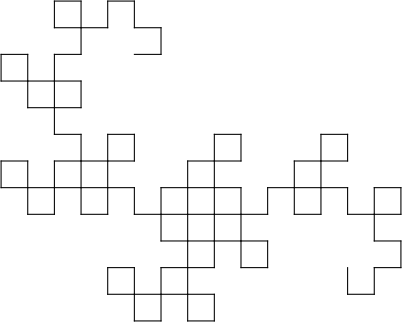

In [4]:
lindenmayer[i_, b_, h_, j_, r_, n_] := 
  (a = h; p = j; s = k = {}; t = Flatten;
    (Switch[#,
      6, s = {a, p, s},
      8, {a, p, s} = s,
      _C, k = {k, Line@{p, p += {Cos@a, Sin@a}}}];
     If[# < 9, a += I^# b ]) & /@ t@Nest[# /. r &, i, n];
    Graphics@t@k);
lindenmayer[{C[1], X}, Pi/2, 0, {0, 0}, {X -> {X, 4, Y, C[1]}, Y -> {C[1], X, 2, Y}}, 7]

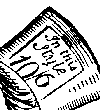

In [5]:
(* Mathics3 also supports Image handling ... *)
alice = Import["ExampleData/MadTeaParty.gif"];
ImageTake[alice, {40, 150}, {500, 600}]

Mathics3 has a lot more. In other notebooks, we show features that Mathics3 has to offer. 

## Mathics3 Jupyter Cell Magics

We have added several Jupyter Cell Magics. These are lines that start with `%%` on the very first line of the cell.

### Python Cell Magic (`%%python` or `%%py`)

Mathics3 is built on top of Python. So if you want to escape back to running Python code, that can be done by starting a cell with
either `%%python` or the shorter `%%py`:

In [6]:
%%python 
[(n * (n+1))// 2  for n in range(1, 6)] # Triangle numbers

[(n * (n+1))// 2  for n in range(1, 6)] # Triangle numbers

[1, 3, 6, 10, 15]

In [7]:
(* Same thing in Mathics3: *)
Table[n (n+1) / 2, {n, 5}]

{ 
 
 1 
 , 
 3 
 , 
 6 
 , 
 10 
 , 
 15 
 
 }

Above, we gave a Python expression. However, Python statements are also accepted:

In [8]:
%%py
# Compute the first 5 triangle numbers.
n = 5
for n in range(1, n + 1):
    print(n * (n + 1) // 2)

# Compute the first 5 triangle numbers.
n = 5
for n in range(1, n + 1):
    print(n * (n + 1) // 2)

1
3
6
10
15


In Python, you have access to the global state available. One additional variable we provide is `session`.
This is the Mathics3 Session object. And from this, you basically have access at the Python level to everything.

In [9]:
%%py
session.last_result

session.last_result

<ListExpression: (<Integer: 1>, <Integer: 3>, <Integer: 6>, <Integer: 10>, <Integer: 15>)>

In [10]:
%%py 
session.last_result.to_python()

session.last_result.to_python()

(1, 3, 6, 10, 15)

### HTML Cell Magic (`%%html`)

For really thorny kinds of things where you want fine control over HTML, there is the `%html` tag. 

As with other magic tags, this must start a line: 

In [11]:
%%html <p>This is <em>some</em> text.</p>

%%html <p>This is <em>some</em> text.</p>